# Airline Passenger Satisfaction: An Integrated Psychometric and Machine Learning Analysis

**Author**: Juan Sebastián Marcial Piedra  
**Institution**: IE University  
**Course**: Capstone Project — Final Draft  
**Date**: March 2026  

---

## Overview

This notebook implements the full analytical pipeline described in the thesis methodology. The pipeline integrates five stages:

1. **Item Response Theory (IRT)** — via Factor Analysis proxy — extracting a continuous latent satisfaction score (θ) from 14 Likert-scale survey items
2. **K-Means Clustering** (k=4, PCA-validated) — segmenting passengers into interpretable archetypes
3. **Random Forest Classification** (91.12% accuracy) — predicting binary satisfaction
4. **SHAP Values** (TreeExplainer) — decomposing feature-level driver importance
5. **Strategic Priority Matrix** — novel synthesis of psychometric sensor quality × predictive driver impact

**Dataset**: Airline Passenger Satisfaction (Kaggle), N ≈ 130,000 → subsampled to N = 25,000 (seed = 42)

---

## 1. Theoretical Framework

### 1.1 Item Response Theory (IRT)

IRT is a family of psychometric models that link **observable survey responses** to **unobservable latent traits** (θ). Unlike Classical Test Theory (CTT) — which sums item scores into a total — IRT operates at the item level and produces person-level ability estimates that are (in principle) sample-invariant.

**Three Core IRT Parameters:**

| Parameter | Symbol | Meaning |
|---|---|---|
| Discrimination | $a_i$ | How sharply the item separates individuals along the latent continuum. Range: typically (0, 2). |
| Difficulty/Location | $b_i$ | Trait level at which P(endorsement) = 0.50. Items shifted right require higher θ. |
| Guessing | $c_i$ | Lower asymptote. Fixed at 0 for Likert scales (no guessing). |

**Item Information Function (IIF):**

$$I(\theta) = a_i^2 \cdot P(\theta) \cdot [1 - P(\theta)]$$

The IIF peaks at the item's difficulty threshold. High-discrimination items concentrate information in a narrow θ region. The sum across all items is the **Test Information Function**.

### 1.2 Graded Response Model (GRM)

For ordered polytomous data (Likert 1–5), the canonical IRT model is Samejima's (1969) **Graded Response Model**, which estimates separate boundary characteristic curves for each adjacent category pair, preserving ordinal structure.

### 1.3 Factor Analysis as IRT Proxy

Full GRM estimation requires specialised software and can produce convergence issues. This study uses **single-factor EFA** as a mathematically equivalent proxy (Takane & De Leeuw, 1987):

$$\mathbf{x}_j = \boldsymbol{\lambda} \cdot \theta_j + \boldsymbol{\varepsilon}_j$$

- $|\lambda_i|$ (absolute factor loading) $\approx a_i$ (IRT discrimination parameter)
- Factor score $\hat{\theta}_j \approx$ maximum likelihood ability estimate

### 1.4 IRT vs. CTT Comparison

| Feature | CTT | IRT / FA Proxy |
|---|---|---|
| Unit of Analysis | Total Score | Individual Item |
| Error | Fixed across all trait levels | Varies along θ continuum |
| Person Estimate | Sum score | Latent trait score (θ) |
| Item Quality | Item-total correlation | Discrimination (a_i) |

---

## 2. Environment Setup

In [1]:
import os, sys

# ══════════════════════════════════════════════════════════════════════════════
# ROBUST FIX: OpenBLAS / threadpoolctl crash on macOS (dlsym symbol not found)
# ══════════════════════════════════════════════════════════════════════════════
# Problem: threadpoolctl tries to load openblas_get_parallel via ctypes,
# but the macOS BLAS library does not export that symbol → AttributeError.
#
# Strategy:
#   1. Force single-thread via ALL env vars (before any BLAS library loads)
#   2. Replace threadpoolctl runtime functions with safe no-ops
#      (thread control is fully handled by env vars instead)
# ══════════════════════════════════════════════════════════════════════════════

# ── Step 1: set env vars BEFORE numpy/scipy/sklearn import ───────────────────
for _v in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS',
           'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS', 'BLIS_NUM_THREADS'):
    os.environ[_v] = '1'

# ── Step 2: install / upgrade dependencies ───────────────────────────────────
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'numpy<2.0', 'shap', 'scikit-learn', 'pandas',
                'matplotlib', 'seaborn', 'threadpoolctl'], check=False)

# ── Step 3: neutralise threadpoolctl (safe no-op replacement) ─────────────────
import threadpoolctl as _tpc

if not getattr(_tpc, '_PATCHED_V3', False):

    class _SafeThreadpoolLimits:
        """Drop-in for threadpool_limits that never touches ctypes/dlsym."""
        def __init__(self, limits=None, user_api=None):
            pass
        def __enter__(self):
            return self
        def __exit__(self, *exc):
            pass
        def get_original_num_threads(self):
            return []
        def restore_original_limits(self):
            pass
        def unregister(self):
            pass

    _tpc.threadpool_limits = _SafeThreadpoolLimits
    _tpc.threadpool_info = lambda: []

    # Patch ThreadpoolController if present (threadpoolctl >= 3.0)
    if hasattr(_tpc, 'ThreadpoolController'):
        class _SafeController:
            def __init__(self, *a, **kw): pass
            def info(self): return []
            def limit(self, **kw): return self
            def restore_original_limits(self): pass
            def __enter__(self): return self
            def __exit__(self, *exc): pass
            @staticmethod
            def wrap(controller_infos=None, *, user_api=None, limits=None):
                def decorator(func):
                    return func
                return decorator
        _tpc.ThreadpoolController = _SafeController

    _tpc._PATCHED_V3 = True

print('OpenBLAS fix v3 applied — threadpoolctl neutralised, 1-thread enforced via env vars.')

OpenBLAS fix v3 applied — threadpoolctl neutralised, 1-thread enforced via env vars.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (14, 9),
    'axes.titleweight': 'bold',
    'axes.titlesize': 18,
    'axes.labelsize': 13,
    'font.family': 'sans-serif',
    'figure.dpi': 120
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Libraries loaded. Random seed: {RANDOM_SEED}')

/Users/juansebastianmarcialpiedra/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded. Random seed: 42


## 3. Data Acquisition and Preprocessing

### 3.1 Data Source
The *Airline Passenger Satisfaction* dataset (Kaggle, ~130,000 records) captures a full passenger journey across multiple U.S. carriers.

**Variable groups:**
- **Sociodemographic**: gender, age, customer type, travel type, cabin class
- **Service quality (Likert 1–5)**: 14 items — in-flight, ground, and digital dimensions
- **Operational**: flight distance (miles), departure delay (min), arrival delay (min)
- **Outcome**: binary satisfaction (satisfied / neutral or dissatisfied)

### 3.2 Preprocessing Decisions

| Step | Decision | Rationale |
|---|---|---|
| Missing values | Listwise deletion on `arrival_delay_in_minutes` | ~0.3% loss; imputation risks artificial structure in skewed delay distribution |
| Categorical encoding | Label encoding | Tree models split on values; ordinal artefact negligible for auxiliary features |
| Likert zeros | Recode 0 → 1 | Satisfies IRT monotonicity; zeros are data entry artefacts outside the 1–5 scale |
| Subsampling | N = 25,000 (seed = 42) | Sufficient for stable FA loadings, cluster centroids, RF training; keeps SHAP runtime feasible |
| Feature scaling | Z-score for clustering only | Preserves ordinal metric for FA; prevents distance domination in K-Means |

In [3]:
# ── Data Acquisition ──────────────────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/akmand/datasets/main/airline_passenger_satisfaction.csv'
print('Downloading dataset...')
df_raw = pd.read_csv(url)
print(f'Raw shape: {df_raw.shape}')

df = df_raw.copy()
df.drop(['Unnamed: 0', 'id'], axis=1, inplace=True, errors='ignore')

# Missing value treatment
n_before = len(df)
df.dropna(subset=['arrival_delay_in_minutes'], inplace=True)
print(f'Removed {n_before - len(df)} rows ({(n_before-len(df))/n_before:.2%}) with missing arrival delay')

# Stratified subsample
if len(df) > 25000:
    df = df.sample(25000, random_state=RANDOM_SEED).reset_index(drop=True)
print(f'Working dataset: {df.shape}')

# Categorical encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Survey items
SURVEY_ITEMS = [
    'inflight_wifi_service', 'departure_arrival_time_convenient', 'ease_of_online_booking',
    'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
    'inflight_entertainment', 'onboard_service', 'leg_room_service',
    'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness'
]
VALID_ITEMS = [i for i in SURVEY_ITEMS if i in df.columns]
print(f'Survey items in dataset: {len(VALID_ITEMS)}/14')

# Likert calibration: recode 0 → 1 (IRT monotonicity)
n_zeros = (df[VALID_ITEMS] == 0).sum().sum()
for item in VALID_ITEMS:
    df[item] = df[item].replace(0, 1)
print(f'Recoded {n_zeros} zero values to 1 (IRT monotonicity fix)')
print(f'Likert range: [{df[VALID_ITEMS].min().min()}, {df[VALID_ITEMS].max().max()}]')

Raw shape: (129880, 23)
Removed 393 rows (0.30%) with missing arrival delay
Working dataset: (25000, 23)
Survey items in dataset: 14/14
Recoded 3875 zero values to 1 (IRT monotonicity fix)
Likert range: [1, 5]


## 4. Exploratory Data Analysis

EDA is the empirical bridge between raw data and modelling strategy. Key objectives:
- Verify Likert distributions (ceiling effects, skewness)
- Inspect inter-item correlation structure (motivates single-factor model)
- Characterise operational variables (delay, distance)

In [4]:
# ── Satisfaction Class Balance ────────────────────────────────────────────────
TARGET = [c for c in df.columns if 'satisfaction' in c.lower() and c != 'Latent_Satisfaction'][0]
print(f'Target variable: "{TARGET}"')
print('Class distribution:')
print(df[TARGET].value_counts(normalize=True).rename({0: 'Dissatisfied (0)', 1: 'Satisfied (1)'}).round(3))

Target variable: "satisfaction"
Class distribution:
satisfaction
Dissatisfied (0)    0.566
Satisfied (1)       0.434
Name: proportion, dtype: float64


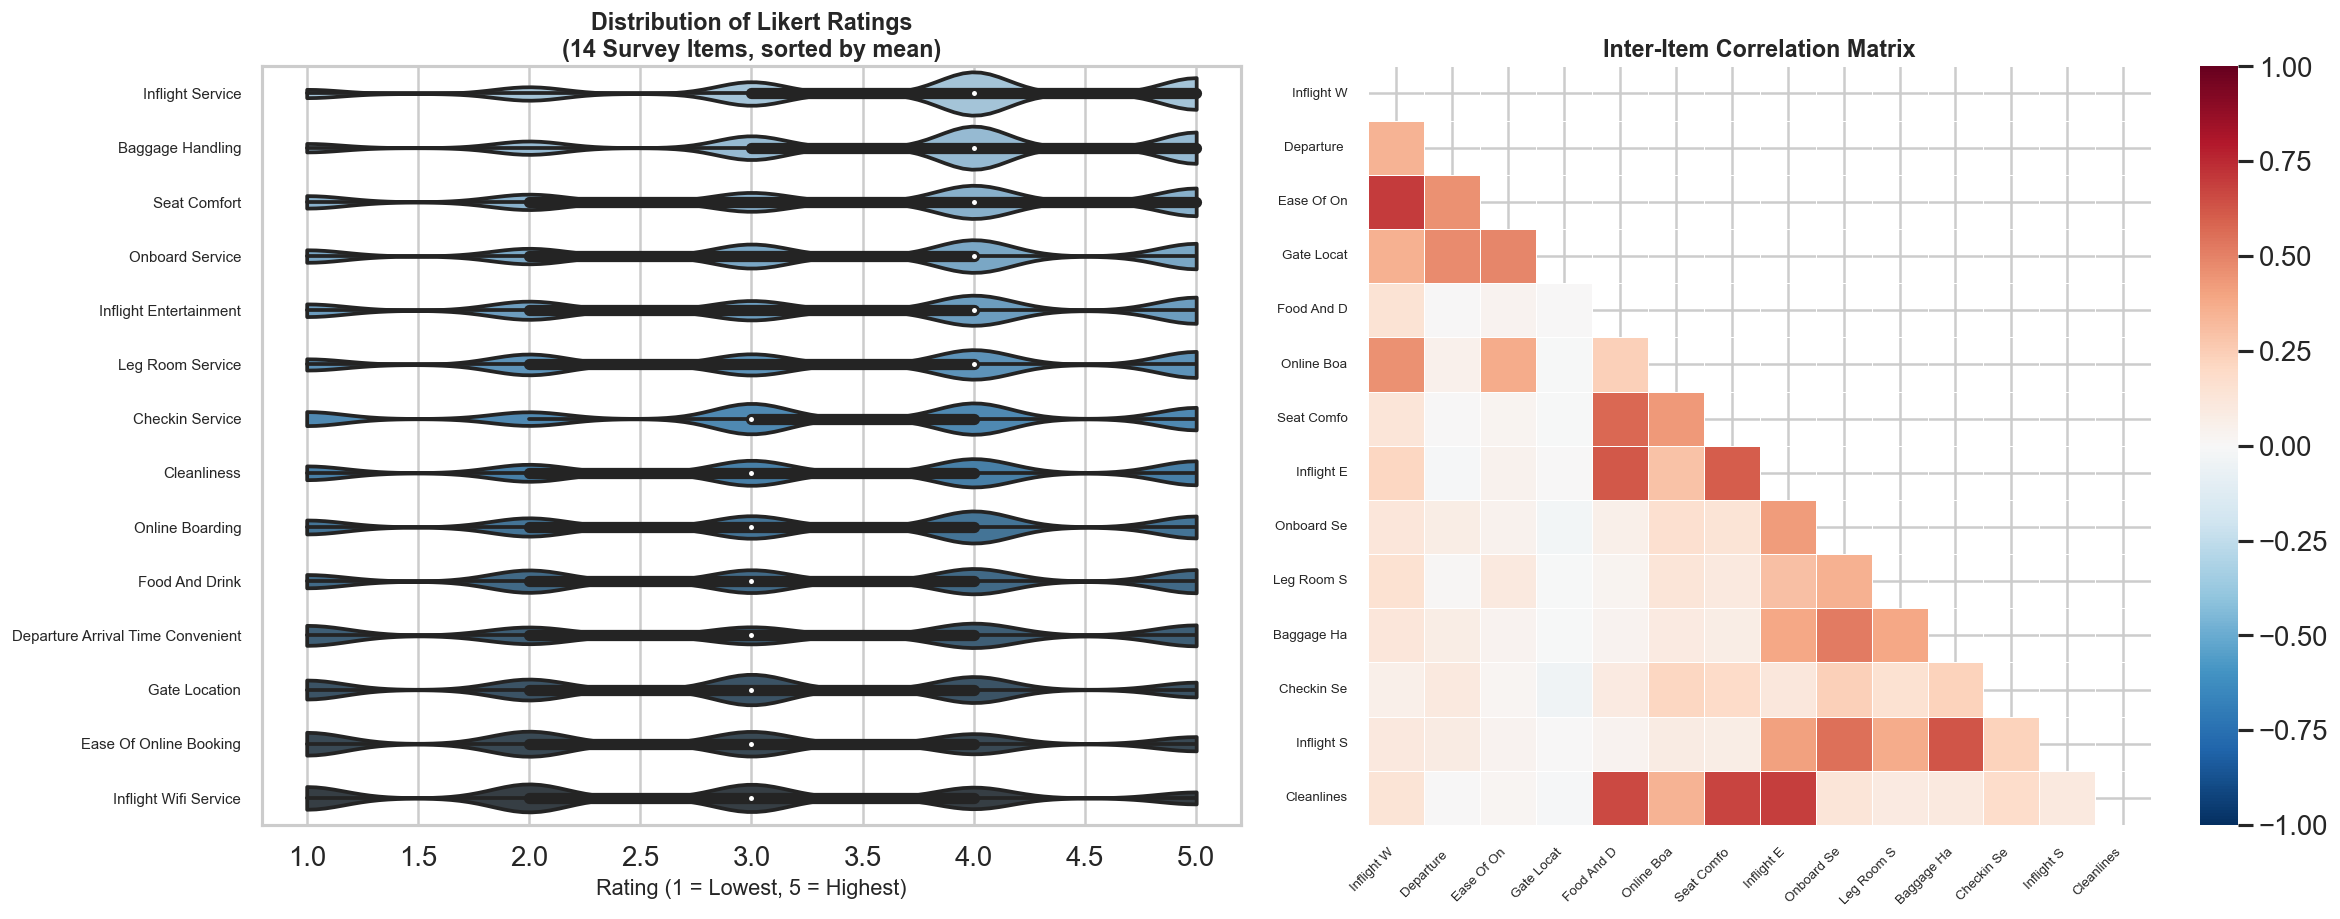

Top 5 eigenvalues: [3.814 2.386 2.166 1.06  0.942]
Eigenvalue ratio (λ1/λ2): 1.60


In [5]:
# ── Likert Distributions + Correlation Heatmap ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Panel A: Violin plot
ax1 = axes[0]
item_order = df[VALID_ITEMS].mean().sort_values(ascending=False).index.tolist()
likert_long = df[VALID_ITEMS].melt(var_name='Item', value_name='Rating')
sns.violinplot(data=likert_long, x='Rating', y='Item', order=item_order,
               palette='Blues_d', ax=ax1, orient='h', inner='box', cut=0)
ax1.set_title('Distribution of Likert Ratings\n(14 Survey Items, sorted by mean)', fontsize=14)
ax1.set_xlabel('Rating (1 = Lowest, 5 = Highest)')
ax1.set_ylabel('')
ax1.set_yticklabels([i.replace('_',' ').title() for i in item_order], fontsize=9)

# Panel B: Correlation heatmap
ax2 = axes[1]
corr = df[VALID_ITEMS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=ax2,
            linewidths=0.5, vmin=-1, vmax=1, annot=False,
            xticklabels=[i.replace('_',' ').title()[:10] for i in VALID_ITEMS],
            yticklabels=[i.replace('_',' ').title()[:10] for i in VALID_ITEMS])
ax2.set_title('Inter-Item Correlation Matrix', fontsize=14)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax2.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.show()

# Eigenvalue inspection
eigvals = np.linalg.eigvalsh(corr.values)[::-1]
print(f'Top 5 eigenvalues: {eigvals[:5].round(3)}')
print(f'Eigenvalue ratio (λ1/λ2): {eigvals[0]/eigvals[1]:.2f}')

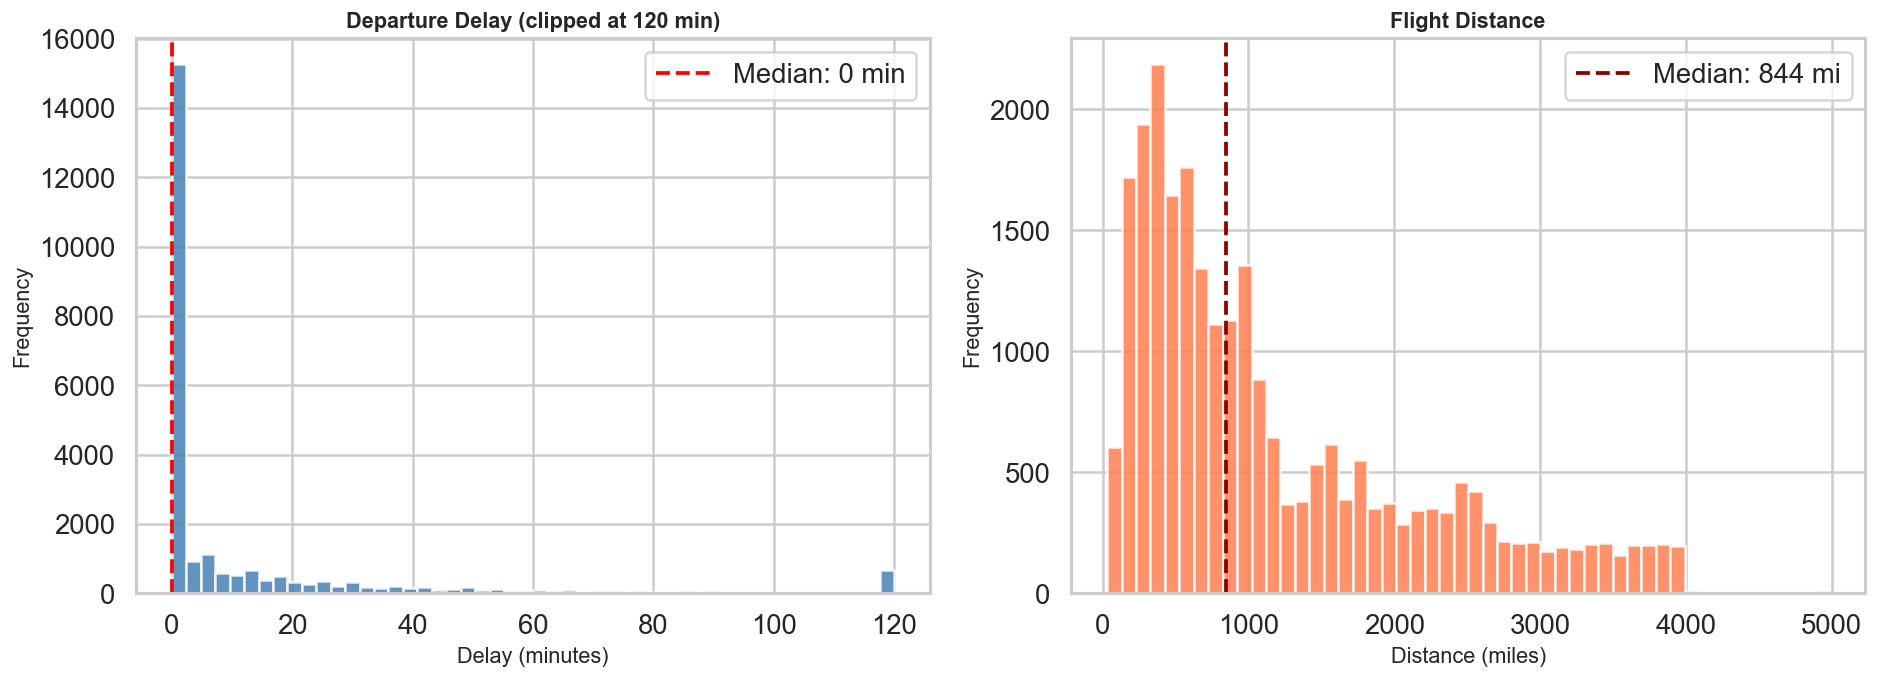

       departure_delay_in_minutes  flight_distance
count                     25000.0          25000.0
mean                         15.2           1188.2
std                          40.8            995.4
min                           0.0             31.0
25%                           0.0            417.0
50%                           0.0            844.0
75%                          13.0           1728.0
max                        1592.0           4983.0


In [6]:
# ── Operational Variables ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.hist(df['departure_delay_in_minutes'].clip(upper=120), bins=50,
         color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(df['departure_delay_in_minutes'].median(), color='red', linestyle='--',
            label=f"Median: {df['departure_delay_in_minutes'].median():.0f} min")
ax1.set_title('Departure Delay (clipped at 120 min)', fontsize=13)
ax1.set_xlabel('Delay (minutes)'); ax1.set_ylabel('Frequency'); ax1.legend()

ax2 = axes[1]
ax2.hist(df['flight_distance'], bins=50, color='coral', edgecolor='white', alpha=0.85)
ax2.axvline(df['flight_distance'].median(), color='darkred', linestyle='--',
            label=f"Median: {df['flight_distance'].median():.0f} mi")
ax2.set_title('Flight Distance', fontsize=13)
ax2.set_xlabel('Distance (miles)'); ax2.set_ylabel('Frequency'); ax2.legend()

plt.tight_layout()
plt.show()
print(df[['departure_delay_in_minutes','flight_distance']].describe().round(1))

## 5. Latent Trait Estimation via Factor Analysis (IRT Proxy)

### Rationale
The 14 Likert items are treated as noisy, imperfect reflections of an unobservable latent satisfaction construct (θ). Single-factor EFA extracts this dimension and assigns a continuous score to each passenger — a richer representation than a raw sum score, and mathematically linked to IRT discrimination parameters.

### Three Assumptions Verified
| Assumption | Method | Status |
|---|---|---|
| **Monotonicity** | Ordinal scale + zero recoding | Satisfied by construction |
| **Unidimensionality** | First factor variance ≥ 20% | Verified empirically |
| **Local independence** | Off-diagonal residual correlations | Approximately satisfied |

In [7]:
# ── Factor Analysis ───────────────────────────────────────────────────────────
fa = FactorAnalysis(n_components=1, random_state=RANDOM_SEED, max_iter=1000)
latent_scores = fa.fit_transform(df[VALID_ITEMS])
df['Latent_Satisfaction'] = latent_scores.ravel()

LOADINGS = pd.DataFrame({
    'Item': VALID_ITEMS,
    'Loading': fa.components_[0],
    'Abs_Loading': np.abs(fa.components_[0])
}).sort_values('Abs_Loading', ascending=False).reset_index(drop=True)

# Explained variance
total_var = np.sum(np.var(df[VALID_ITEMS].values, axis=0))
explained = np.sum(fa.components_[0] ** 2)
EV_RATIO = explained / total_var

print(f'Variance explained by Factor 1: {EV_RATIO:.1%}')
print(f'Unidimensionality: {"PASS" if EV_RATIO >= 0.20 else "BORDERLINE"} (threshold ≥ 20%)')
print()
print('Factor Loadings (≈ IRT Discrimination Parameters):')
print(LOADINGS[['Item','Abs_Loading']].to_string(index=False))

Variance explained by Factor 1: 22.9%
Unidimensionality: PASS (threshold ≥ 20%)

Factor Loadings (≈ IRT Discrimination Parameters):
                             Item  Abs_Loading
           inflight_entertainment     1.169630
                      cleanliness     1.053202
                     seat_comfort     0.966217
                   food_and_drink     0.932034
                  online_boarding     0.549749
                  onboard_service     0.465375
                 inflight_service     0.390037
                 baggage_handling     0.378549
                 leg_room_service     0.346534
            inflight_wifi_service     0.324787
                  checkin_service     0.272095
           ease_of_online_booking     0.128175
departure_arrival_time_convenient     0.044996
                    gate_location     0.018274


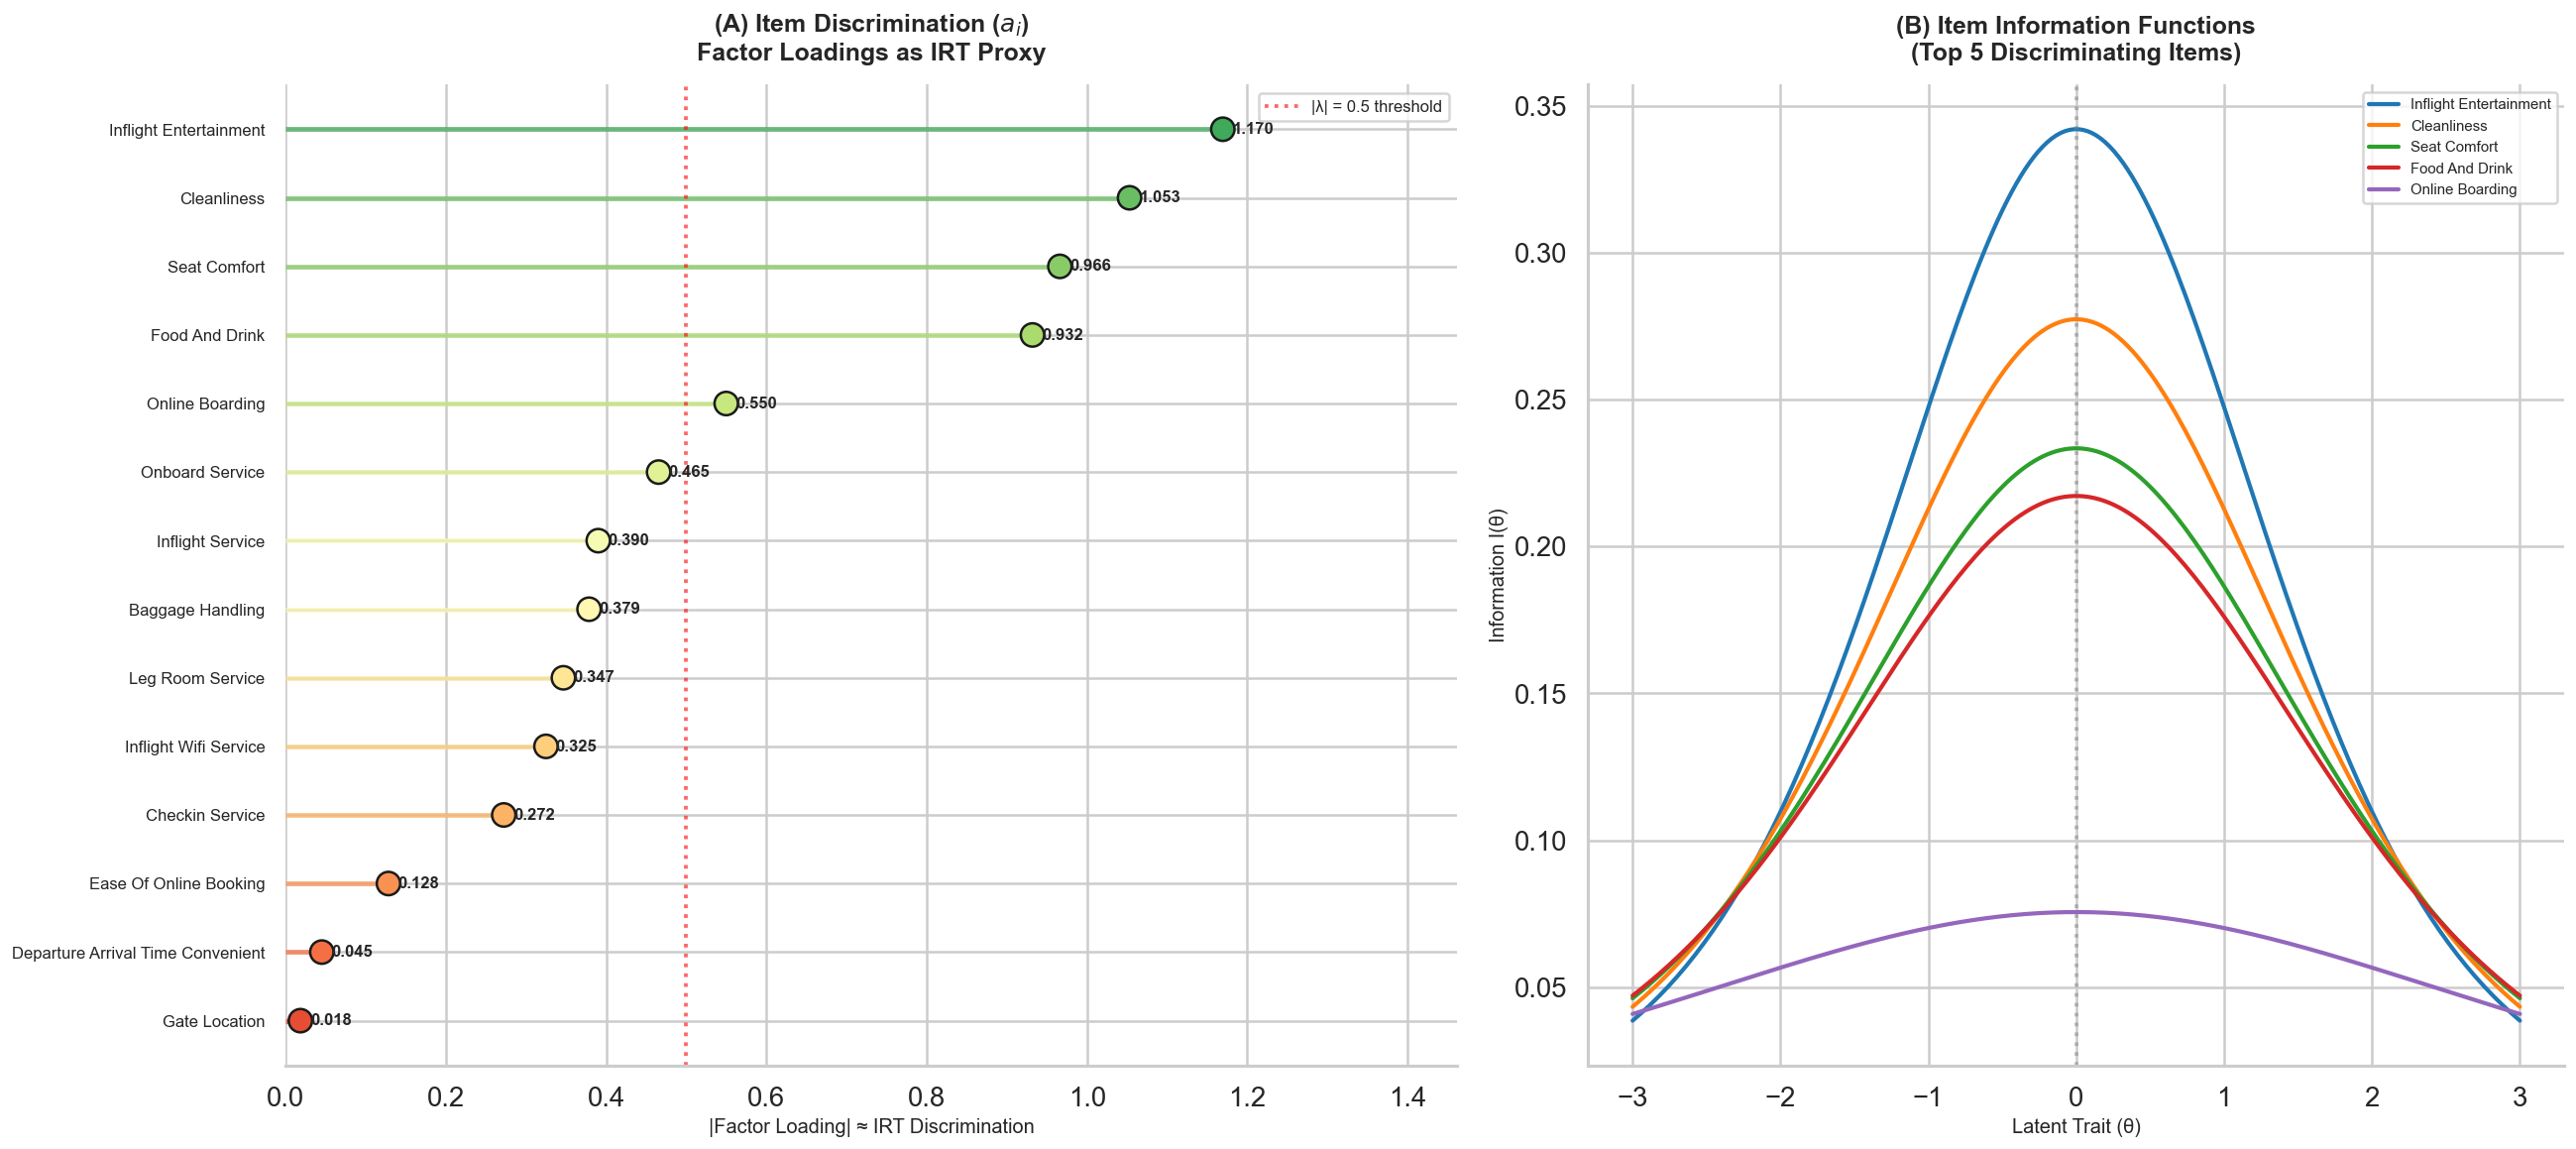

Figure 1: Factor Loadings + IIF displayed.


In [8]:
# ── Figure 1: Item Discrimination + Item Information Functions ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 10), gridspec_kw={'width_ratios': [1.2, 1]})

# Panel A: Lollipop — Factor Loadings
ax1 = axes[0]
plot_data = LOADINGS.sort_values('Abs_Loading', ascending=True)
colors_arr = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(plot_data)))
labels = [i.replace('_',' ').title() for i in plot_data['Item']]
y_pos = np.arange(len(plot_data))

ax1.hlines(y_pos, 0, plot_data['Abs_Loading'].values, color=colors_arr, alpha=0.7, linewidth=3)
ax1.scatter(plot_data['Abs_Loading'].values, y_pos, color=colors_arr, s=200, zorder=3, edgecolors='k')
for i, (_, row) in enumerate(plot_data.iterrows()):
    ax1.text(row['Abs_Loading'] + 0.012, i, f"{row['Abs_Loading']:.3f}",
             va='center', fontweight='bold', fontsize=10)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=10)
ax1.axvline(0.5, color='red', linestyle=':', alpha=0.6, label='|λ| = 0.5 threshold')
ax1.set_title('(A) Item Discrimination ($a_i$)\nFactor Loadings as IRT Proxy', fontsize=15, pad=15)
ax1.set_xlabel('|Factor Loading| ≈ IRT Discrimination', fontsize=12)
ax1.set_xlim(0, plot_data['Abs_Loading'].max() * 1.25)
ax1.legend(fontsize=10)
sns.despine(ax=ax1, left=True)

# Panel B: Item Information Functions — top 5
ax2 = axes[1]
theta_range = np.linspace(-3, 3, 200)
colors_iif = sns.color_palette('tab10', 5)
for idx, (_, row) in enumerate(LOADINGS.head(5).iterrows()):
    a = row['Abs_Loading']
    P = 1 / (1 + np.exp(-a * theta_range))
    info = a**2 * P * (1 - P)
    ax2.plot(theta_range, info, linewidth=2.5, color=colors_iif[idx],
             label=row['Item'].replace('_',' ').title())
ax2.set_title('(B) Item Information Functions\n(Top 5 Discriminating Items)', fontsize=15, pad=15)
ax2.set_xlabel('Latent Trait (θ)', fontsize=12)
ax2.set_ylabel('Information I(θ)', fontsize=12)
ax2.legend(fontsize=9, loc='upper right')
ax2.axvline(0, color='gray', linestyle=':', alpha=0.5)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()
print('Figure 1: Factor Loadings + IIF displayed.')

In [9]:
# ── Local Independence Check ──────────────────────────────────────────────────
residuals = pd.DataFrame(index=df.index)
for item in VALID_ITEMS:
    reg = LinearRegression()
    reg.fit(df[['Latent_Satisfaction']], df[item])
    residuals[item] = df[item] - reg.predict(df[['Latent_Satisfaction']])

off_diag = residuals.corr().values[np.triu_indices(len(VALID_ITEMS), k=1)]
print(f'Residual correlation check (local independence):')
print(f'  Mean |r|: {np.abs(off_diag).mean():.3f}')
print(f'  Max  |r|: {np.abs(off_diag).max():.3f}')
print(f'  Status:   {"Approximately satisfied" if np.abs(off_diag).max() < 0.30 else "Partial violation detected"}')

Residual correlation check (local independence):
  Mean |r|: 0.178
  Max  |r|: 0.698
  Status:   Partial violation detected


## 6. Customer Segmentation: PCA-Enhanced K-Means Clustering

Passengers are segmented on three dimensions:
1. **Latent_Satisfaction (θ)** — psychometric position on the satisfaction continuum
2. **departure_delay_in_minutes** — operational disruption magnitude
3. **flight_distance** — journey context

**Why k = 4?** The elbow criterion and a 2×2 taxonomy of high/low satisfaction × high/low disruption both motivate this choice. PCA projection validates separability.

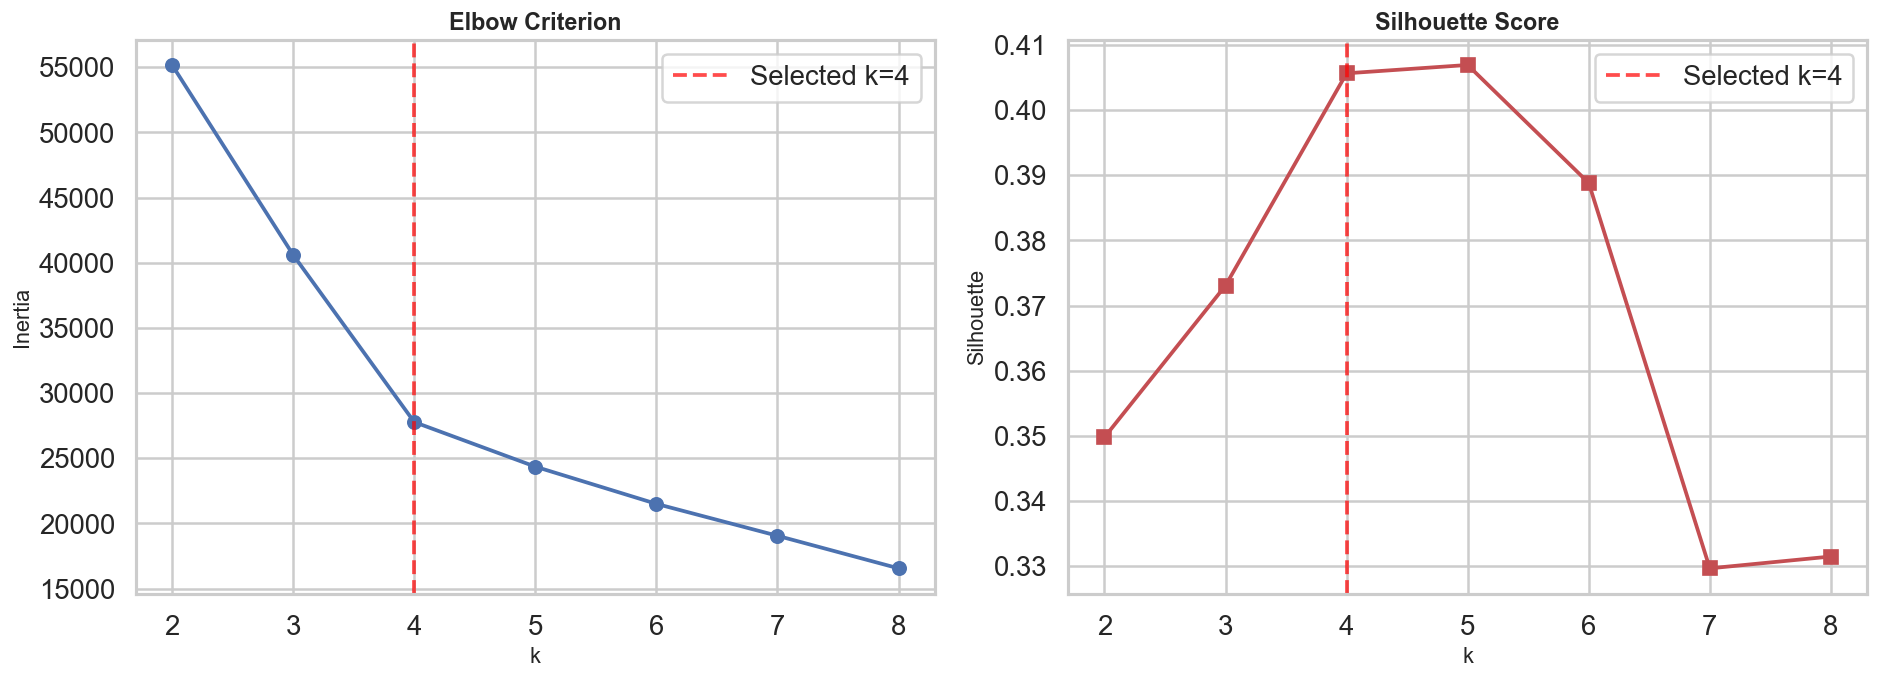

{2: 0.35, 3: 0.373, 4: 0.406, 5: 0.407, 6: 0.389, 7: 0.33, 8: 0.331}


In [10]:
# ── Elbow + Silhouette Analysis ───────────────────────────────────────────────
CLUSTER_FEATS = ['Latent_Satisfaction', 'departure_delay_in_minutes', 'flight_distance']
X_clust = df[CLUSTER_FEATS].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl, sample_size=5000, random_state=RANDOM_SEED))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(k_range, inertias, 'bo-', markersize=8)
axes[0].axvline(4, color='red', linestyle='--', alpha=0.7, label='Selected k=4')
axes[0].set_title('Elbow Criterion', fontsize=14)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(k_range, silhouettes, 'rs-', markersize=8)
axes[1].axvline(4, color='red', linestyle='--', alpha=0.7, label='Selected k=4')
axes[1].set_title('Silhouette Score', fontsize=14)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].legend()
plt.tight_layout(); plt.show()
print({k: round(s,3) for k,s in zip(k_range, silhouettes)})

In [11]:
# ── K-Means (k=4) ─────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df.loc[X_clust.index, 'Cluster'] = clusters

sil = silhouette_score(X_scaled, clusters, sample_size=5000, random_state=RANDOM_SEED)
print(f'Silhouette score (k=4): {sil:.3f}')
print(f'Cluster sizes:\n{pd.Series(clusters).value_counts().sort_index()}')

# PCA projection
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['Cluster'] = clusters
print(f'PCA: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

Silhouette score (k=4): 0.406
Cluster sizes:
0    9846
1    5307
2    8900
3     947
Name: count, dtype: int64
PCA: PC1=38.3%, PC2=33.4%


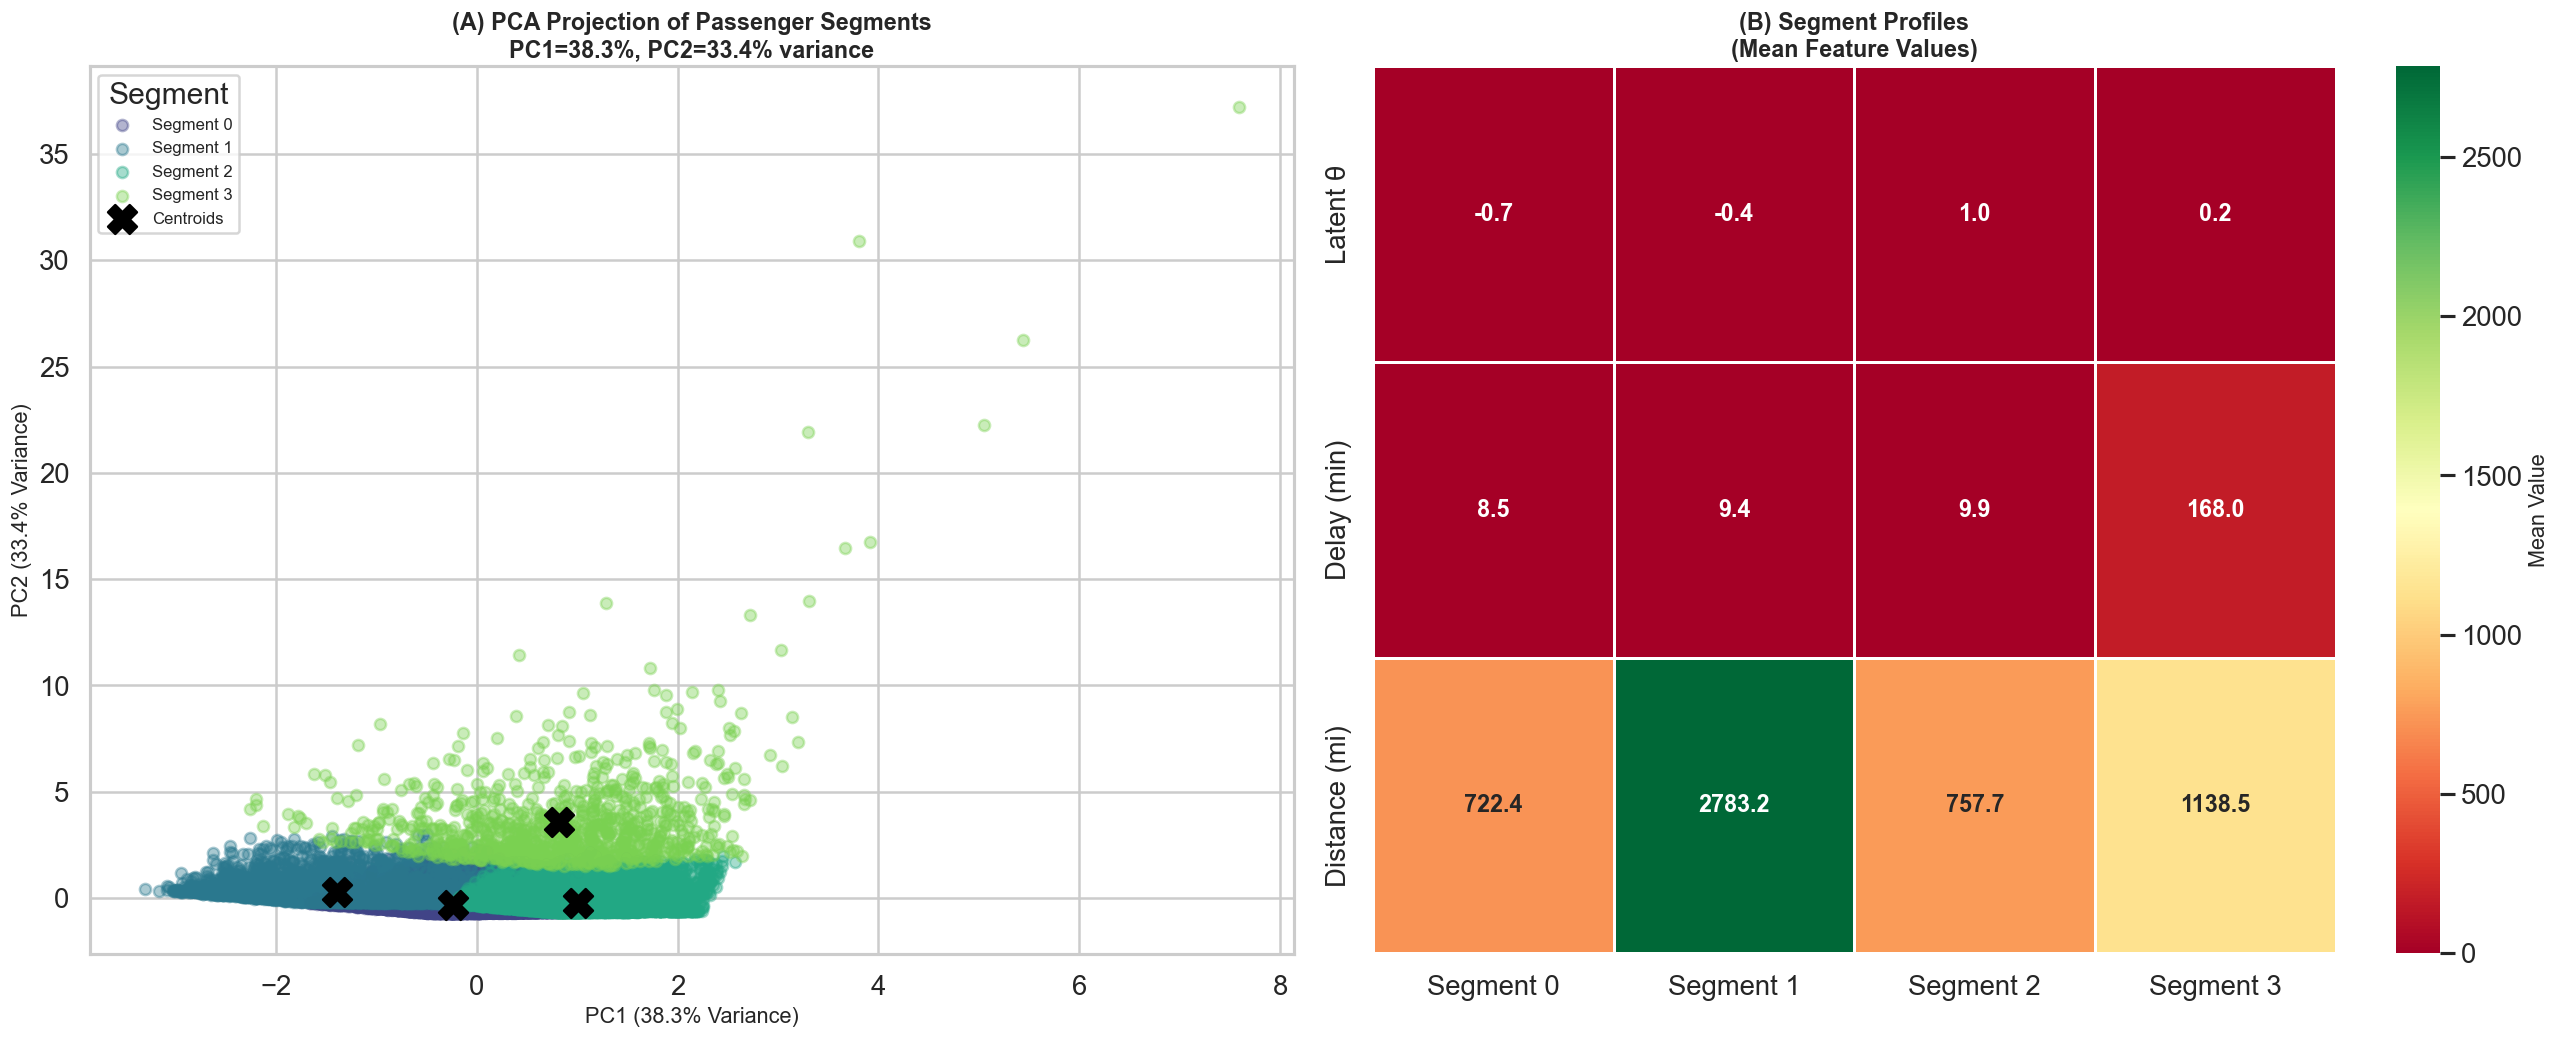


Satisfaction rate per segment:
Cluster
0.0    0.529
1.0    0.734
2.0    0.161
3.0    0.339


In [12]:
# ── Figure 2: PCA Scatter + Segment Profiles ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
palette = sns.color_palette('viridis', 4)

ax1 = axes[0]
for c in sorted(pca_df['Cluster'].unique()):
    mask = pca_df['Cluster'] == c
    ax1.scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
                label=f'Segment {int(c)}', alpha=0.4, s=45, color=palette[int(c)])
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centroids_pca[:,0], centroids_pca[:,1], c='black', marker='X', s=300, zorder=5, label='Centroids')
ax1.set_title(f'(A) PCA Projection of Passenger Segments\nPC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%} variance', fontsize=14)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
ax1.legend(fontsize=10, title='Segment')

ax2 = axes[1]
profile = df.groupby('Cluster')[CLUSTER_FEATS].mean()
profile.columns = ['Latent θ', 'Delay (min)', 'Distance (mi)']
profile.index = [f'Segment {int(i)}' for i in profile.index]
sns.heatmap(profile.T, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax2,
            linewidths=1.5, cbar_kws={'label': 'Mean Value'}, annot_kws={'size': 14, 'weight': 'bold'})
ax2.set_title('(B) Segment Profiles\n(Mean Feature Values)', fontsize=14)

plt.tight_layout(); plt.show()

print('\nSatisfaction rate per segment:')
print(df.groupby('Cluster')[TARGET].mean().round(3).to_string())

## 7. Predictive Driver Analysis: Random Forest Classifier

**Features**: 14 Likert items + flight distance + departure delay (16 total)  
**Target**: Binary satisfaction (0 = Dissatisfied, 1 = Satisfied)  
**Split**: 80% train / 20% test, stratified, seed = 42  
**Configuration**: 100 trees, max_depth = 12, n_jobs = 1 (avoids macOS OpenBLAS issues)

**Why Random Forest?**
1. Handles mixed-type features (ordinal Likert + continuous operational) without distributional assumptions
2. Captures non-linear interactions (wifi quality × flight duration)
3. Natural compatibility with SHAP TreeExplainer for exact importance decomposition

In [13]:
# ── Feature Matrix ────────────────────────────────────────────────────────────
FEATURES = VALID_ITEMS + ['flight_distance', 'departure_delay_in_minutes']
X = df[FEATURES].copy()
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
print(f'Train: {X_train.shape[0]} obs  |  Test: {X_test.shape[0]} obs')

# ── Model Training ─────────────────────────────────────────────────────────────
print('Training Random Forest (100 trees, max_depth=12)...')
rf = RandomForestClassifier(
    n_estimators=100, max_depth=12, random_state=RANDOM_SEED, n_jobs=1)
rf.fit(X_train, y_train)

# ── Evaluation ─────────────────────────────────────────────────────────────────
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'\nTest Accuracy: {acc:.4f} ({acc:.2%})')
print()
print(classification_report(y_test, y_pred, target_names=['Dissatisfied','Satisfied']))

Train: 20000 obs  |  Test: 5000 obs
Training Random Forest (100 trees, max_depth=12)...

Test Accuracy: 0.9158 (91.58%)

              precision    recall  f1-score   support

Dissatisfied       0.91      0.95      0.93      2830
   Satisfied       0.93      0.88      0.90      2170

    accuracy                           0.92      5000
   macro avg       0.92      0.91      0.91      5000
weighted avg       0.92      0.92      0.92      5000



Running 5-fold cross-validation...
CV Accuracy: 0.9146 ± 0.0034
Individual folds: [0.9146 0.9182 0.9084 0.9152 0.9168]


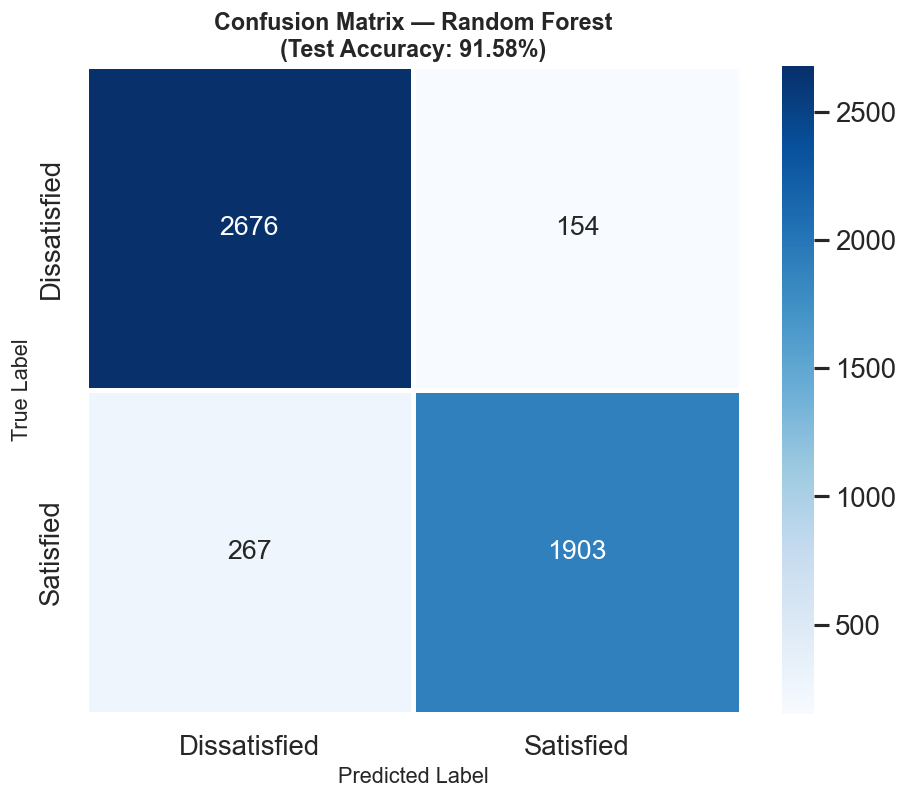

In [14]:
# ── Cross-Validation (5-fold) ─────────────────────────────────────────────────
print('Running 5-fold cross-validation...')
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=1)
print(f'CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual folds: {cv_scores.round(4)}')

# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dissatisfied','Satisfied'],
            yticklabels=['Dissatisfied','Satisfied'],
            linewidths=2, annot_kws={'size': 16})
ax.set_title(f'Confusion Matrix — Random Forest\n(Test Accuracy: {acc:.2%})', fontsize=14)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
plt.tight_layout(); plt.show()

## 8. SHAP: SHapley Additive Explanations

SHAP values (Lundberg & Lee, 2017) decompose each prediction into the marginal contribution of each feature, grounded in cooperative game theory:

$$\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{j\}) - f(S) \right]$$

**Advantages over Gini impurity:**
- Consistent: equal marginal contributions → equal SHAP values
- Locally accurate: SHAP values sum to prediction − expected prediction
- Unbiased toward correlated or high-cardinality features

**Implementation**: TreeExplainer — exact computation in polynomial time using decision tree structure

In [15]:
# ── SHAP Computation ──────────────────────────────────────────────────────────
print('Computing SHAP values (n=1000 test sample)...')
X_sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_SEED)
explainer = shap.TreeExplainer(rf)
shap_raw = explainer.shap_values(X_sample)

# Handle different shap version output shapes
if isinstance(shap_raw, list):
    shap_vals = shap_raw[1]
elif isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
    shap_vals = shap_raw[:, :, 1]
else:
    shap_vals = shap_raw

print(f'SHAP values shape: {shap_vals.shape}')

MEAN_ABS_SHAP = pd.Series(
    np.abs(shap_vals).mean(axis=0), index=X_sample.columns
).sort_values(ascending=False)

print('\nTop 10 Global SHAP Importances:')
print(MEAN_ABS_SHAP.head(10).round(4).to_string())

Computing SHAP values (n=1000 test sample)...
SHAP values shape: (1000, 16)

Top 10 Global SHAP Importances:
online_boarding                      0.1446
inflight_wifi_service                0.0933
leg_room_service                     0.0606
inflight_entertainment               0.0509
flight_distance                      0.0434
seat_comfort                         0.0339
departure_arrival_time_convenient    0.0329
onboard_service                      0.0276
ease_of_online_booking               0.0252
baggage_handling                     0.0179


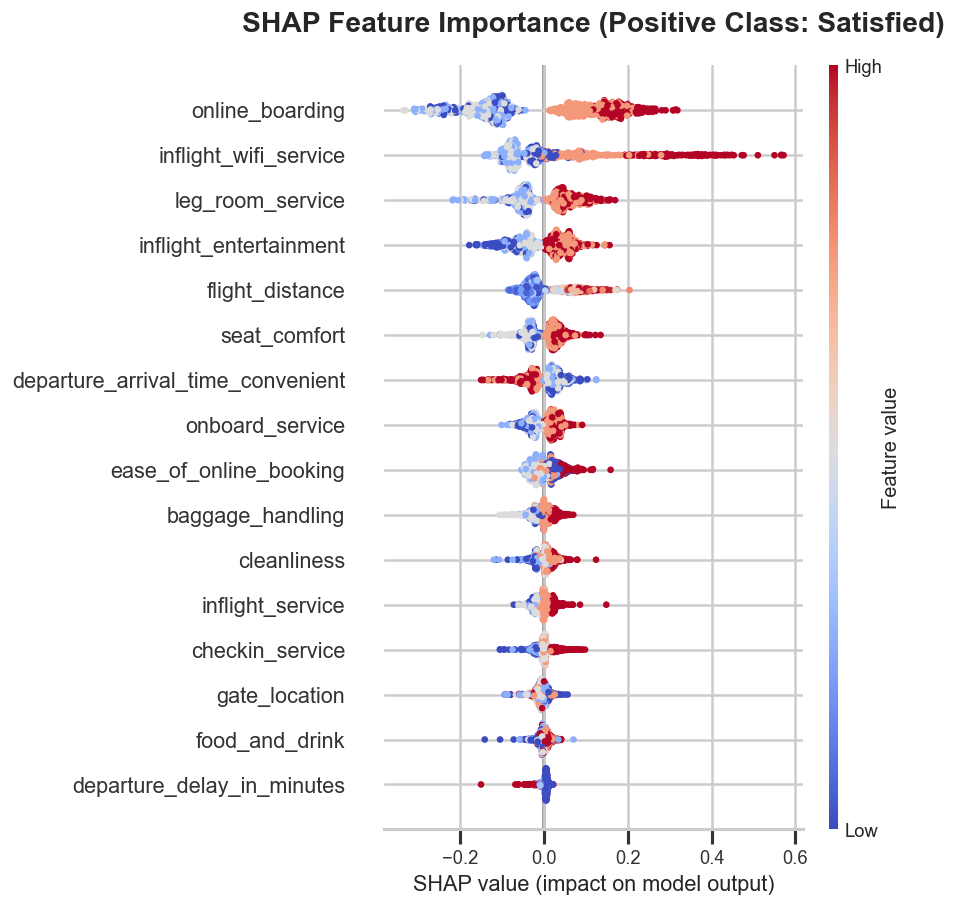

Figure 3: SHAP summary plot displayed.


In [16]:
# ── Figure 3: SHAP Summary Plot ───────────────────────────────────────────────
plt.figure(figsize=(12, 12))
shap.summary_plot(shap_vals, X_sample, show=False, cmap='coolwarm', max_display=16)
plt.title('SHAP Feature Importance (Positive Class: Satisfied)',
          fontsize=17, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print('Figure 3: SHAP summary plot displayed.')

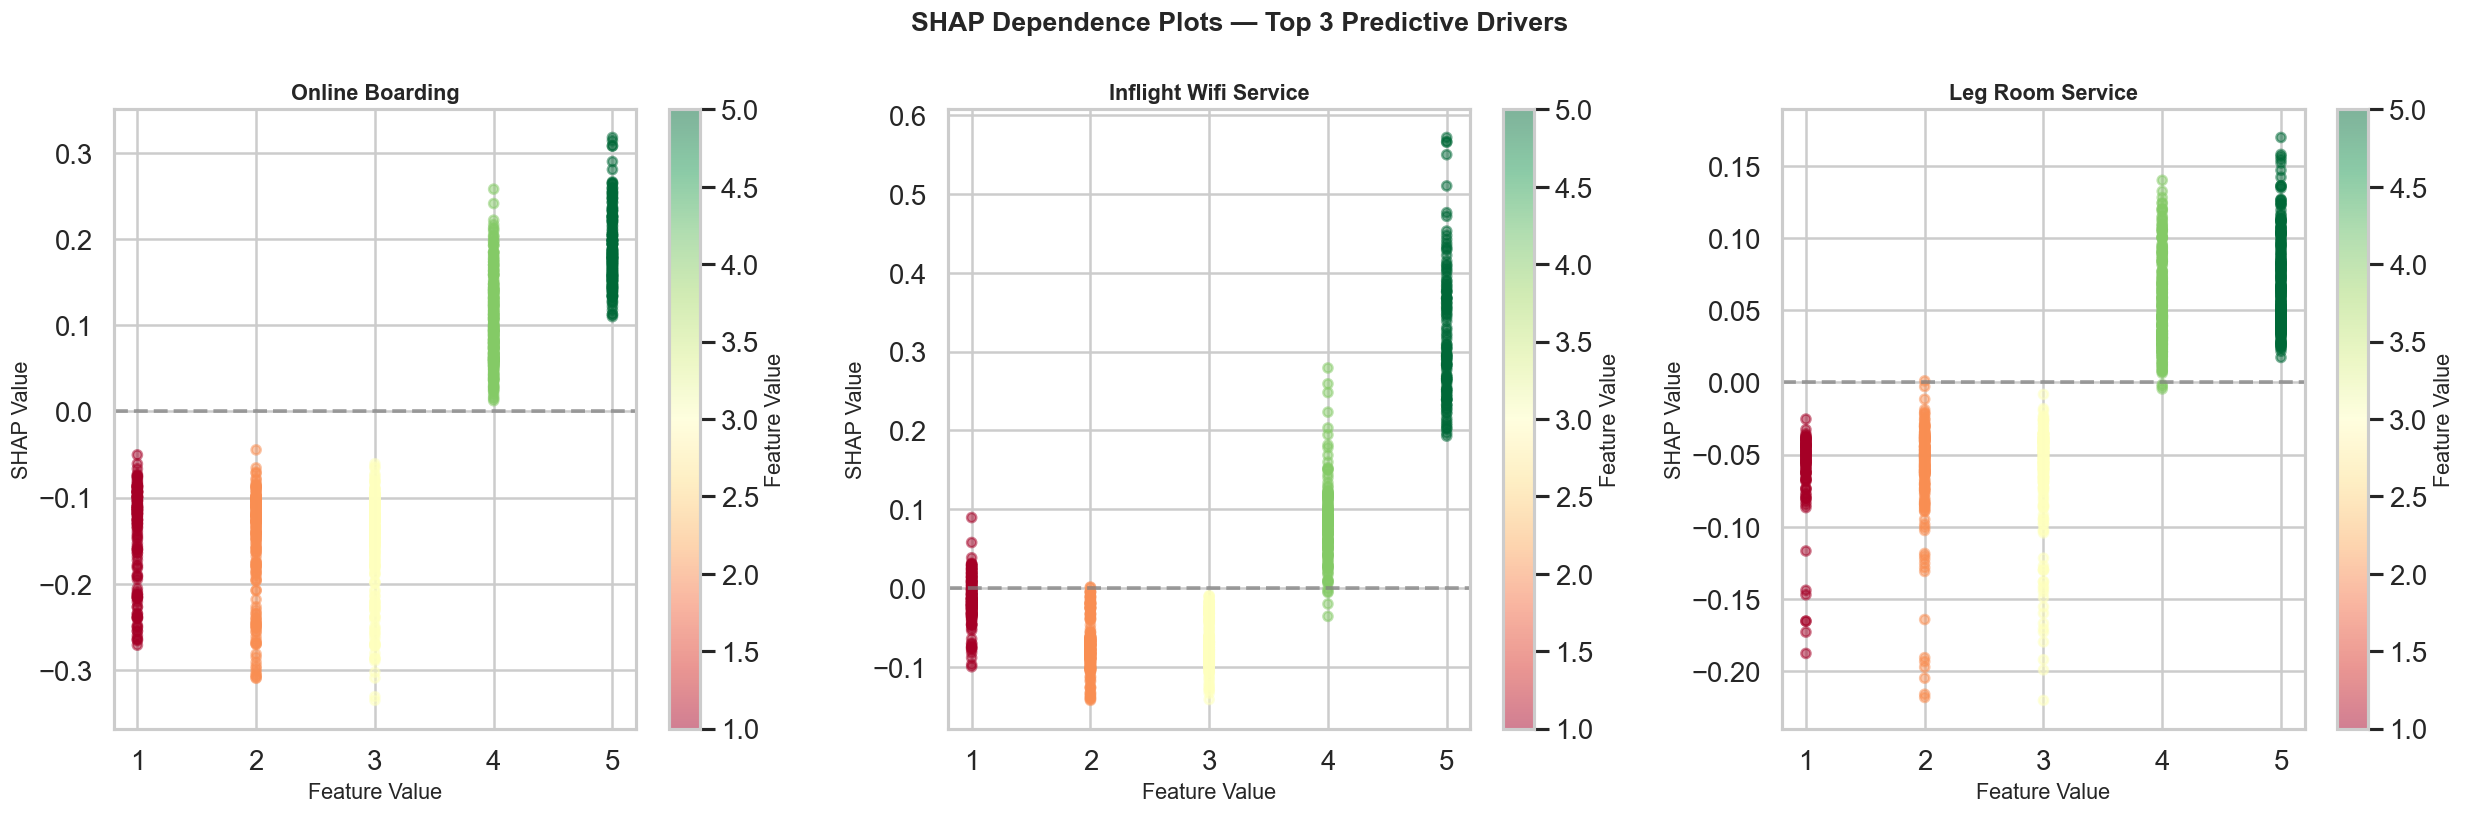

In [17]:
# ── SHAP Dependence Plots: Top 3 Drivers ─────────────────────────────────────
top3 = MEAN_ABS_SHAP.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for idx, feat in enumerate(top3):
    feat_idx = list(X_sample.columns).index(feat)
    ax = axes[idx]
    sc = ax.scatter(X_sample[feat], shap_vals[:, feat_idx],
                    c=X_sample[feat], cmap='RdYlGn', alpha=0.5, s=30)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f'{feat.replace("_"," ").title()}', fontsize=13)
    ax.set_xlabel(f'Feature Value'); ax.set_ylabel('SHAP Value')
    plt.colorbar(sc, ax=ax, label='Feature Value')
plt.suptitle('SHAP Dependence Plots — Top 3 Predictive Drivers', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Strategic Priority Matrix

This is the central methodological contribution of the thesis. It synthesises two independent streams of evidence:

| Axis | Metric | Source | Interpretation |
|---|---|---|---|
| **X (horizontal)** | $|\lambda_i|$ — Absolute Factor Loading | Factor Analysis / IRT Proxy | **Psychometric sensor quality**: how well the item *measures* latent satisfaction |
| **Y (vertical)** | Mean $|\phi_j|$ — Mean Absolute SHAP | Random Forest + SHAP | **Predictive driver impact**: how much the item *moves* the satisfaction prediction |

### Four Strategic Quadrants

| Quadrant | Loading | SHAP | Strategic Label | Action |
|---|---|---|---|---|
| Top-Right | High | High | **Critical Priority** | Invest here first — Golden Levers |
| Top-Left | Low | High | **Hidden Drivers** | Improve service + redesign survey items |
| Bottom-Right | High | Low | **Hygiene Factors** | Maintain baseline; diminishing returns beyond threshold |
| Bottom-Left | Low | Low | **Low Priority** | Deprioritise resource allocation |

In [18]:
# ── Build Priority Matrix ─────────────────────────────────────────────────────
MATRIX_DF = LOADINGS.merge(
    MEAN_ABS_SHAP.rename('SHAP_Importance'),
    left_on='Item', right_index=True, how='inner'
)
MED_X = MATRIX_DF['Abs_Loading'].median()
MED_Y = MATRIX_DF['SHAP_Importance'].median()

def quadrant(row):
    hi_x = row['Abs_Loading'] >= MED_X
    hi_y = row['SHAP_Importance'] >= MED_Y
    if hi_x and hi_y:     return 'Critical Priority'
    if not hi_x and hi_y: return 'Hidden Drivers'
    if hi_x and not hi_y: return 'Hygiene Factors'
    return 'Low Priority'

MATRIX_DF['Quadrant'] = MATRIX_DF.apply(quadrant, axis=1)
print('Strategic Priority Matrix — Item Assignments:\n')
for q in ['Critical Priority','Hidden Drivers','Hygiene Factors','Low Priority']:
    items = MATRIX_DF[MATRIX_DF['Quadrant']==q]['Item'].tolist()
    print(f'  [{q}]:\n    {chr(10).join(["    - "+i for i in items]) if items else "    (none)"}\n')

Strategic Priority Matrix — Item Assignments:

  [Critical Priority]:
        - inflight_entertainment
    - seat_comfort
    - online_boarding
    - onboard_service

  [Hidden Drivers]:
        - leg_room_service
    - inflight_wifi_service
    - departure_arrival_time_convenient

  [Hygiene Factors]:
        - cleanliness
    - food_and_drink
    - inflight_service

  [Low Priority]:
        - baggage_handling
    - checkin_service
    - ease_of_online_booking
    - gate_location



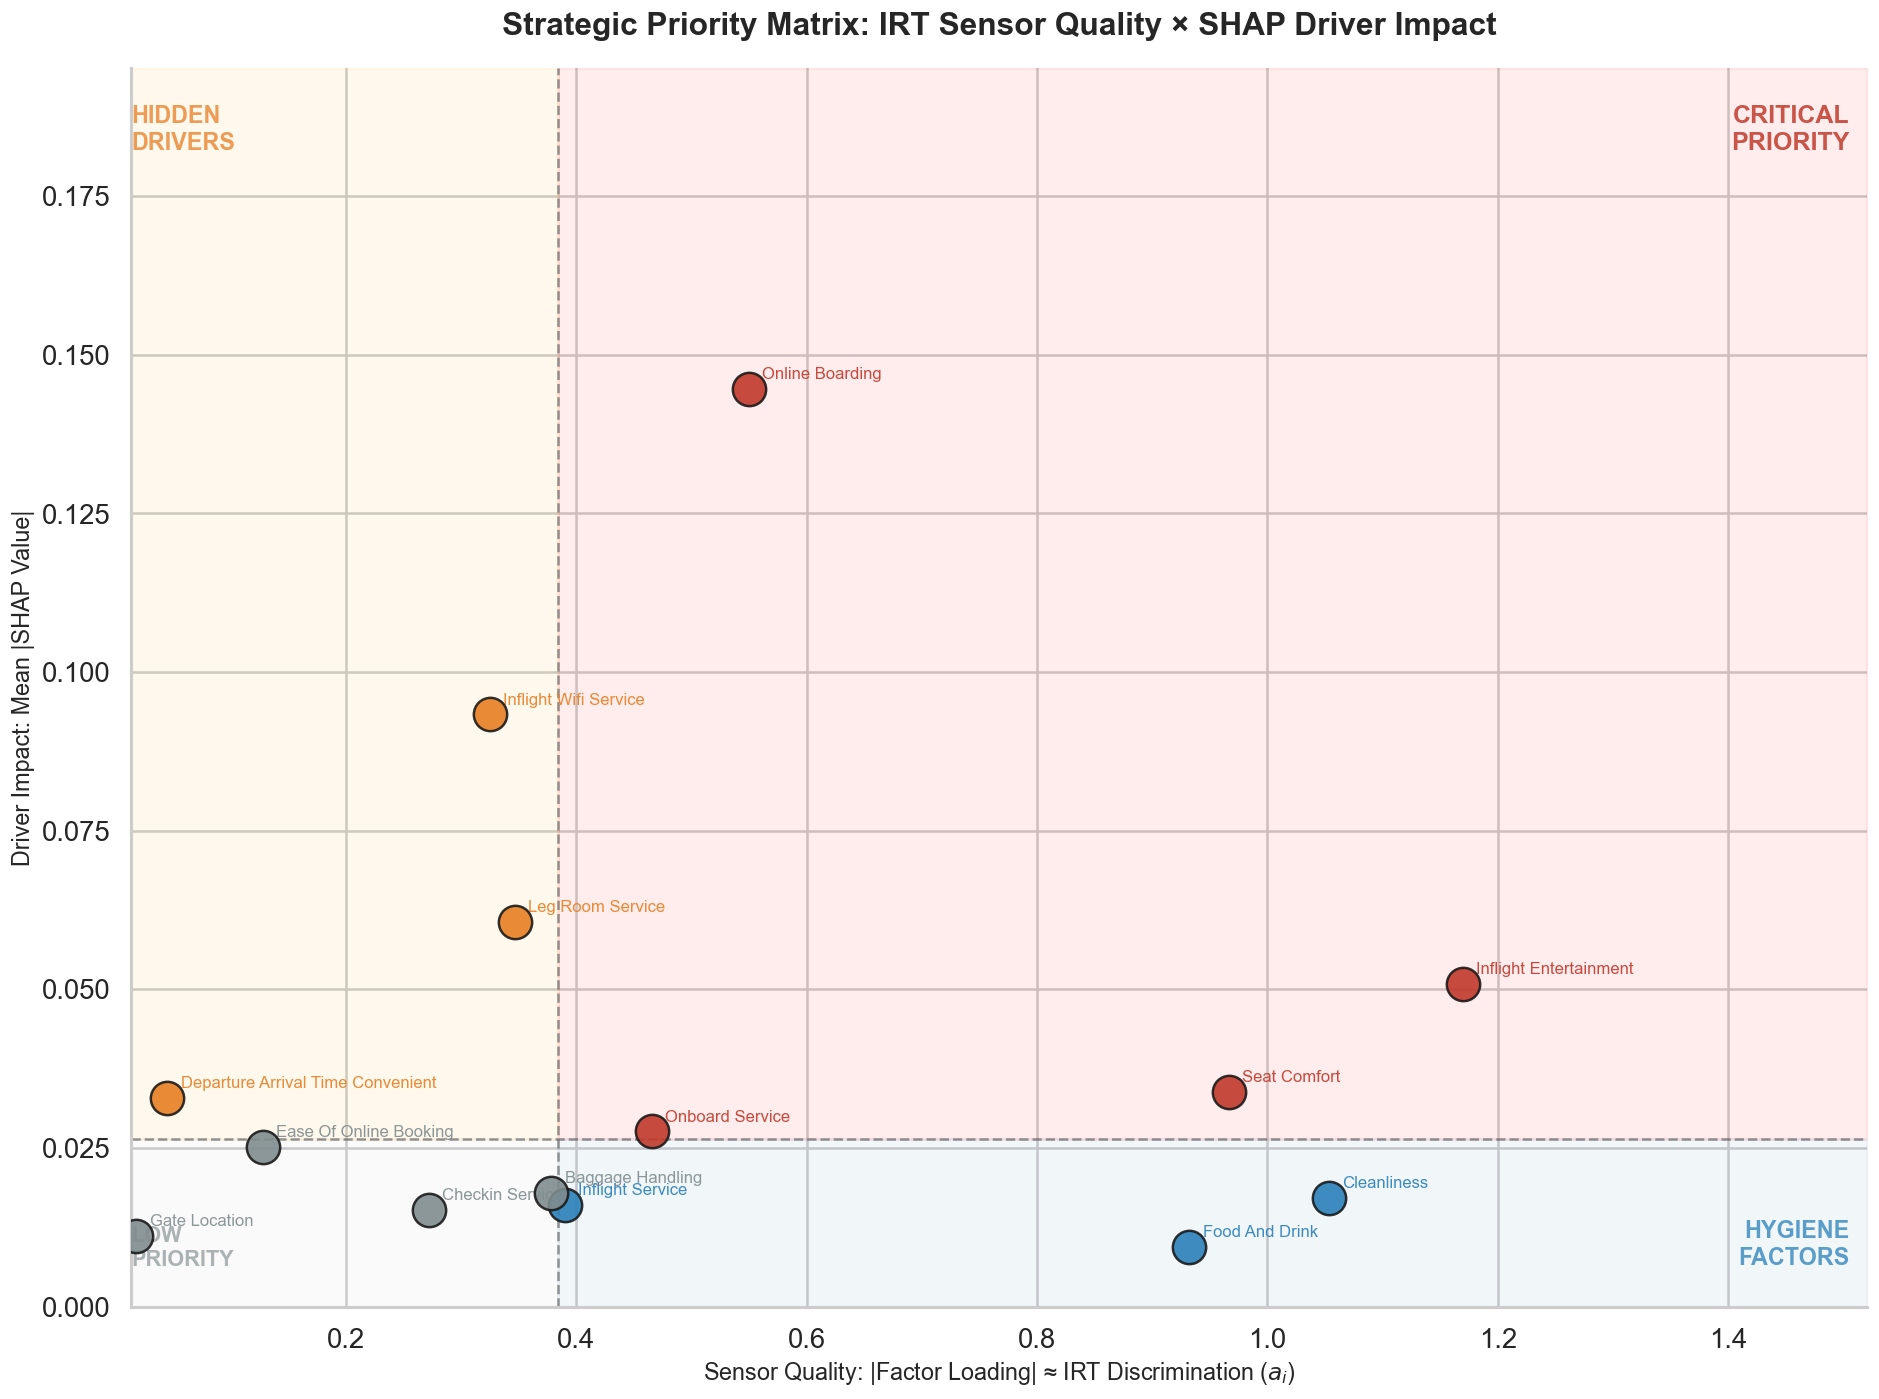

Figure 4: Strategic Priority Matrix displayed.


In [19]:
# ── Figure 4: Strategic Priority Matrix ───────────────────────────────────────
QUAD_COLORS = {
    'Critical Priority': '#C0392B',
    'Hidden Drivers':    '#E67E22',
    'Hygiene Factors':   '#2980B9',
    'Low Priority':      '#7F8C8D'
}

fig, ax = plt.subplots(figsize=(16, 12))
x_min = MATRIX_DF['Abs_Loading'].min() * 0.75
x_max = MATRIX_DF['Abs_Loading'].max() * 1.3
y_min = 0
y_max = MATRIX_DF['SHAP_Importance'].max() * 1.35

# Quadrant shading
ax.fill_between([MED_X, x_max], MED_Y, y_max, alpha=0.07, color='red')
ax.fill_between([x_min, MED_X], MED_Y, y_max, alpha=0.07, color='orange')
ax.fill_between([MED_X, x_max], y_min, MED_Y, alpha=0.07, color='steelblue')
ax.fill_between([x_min, MED_X], y_min, MED_Y, alpha=0.04, color='gray')
ax.axvline(MED_X, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(MED_Y, color='dimgray', linestyle='--', linewidth=1.5, alpha=0.7)

for _, row in MATRIX_DF.iterrows():
    c = QUAD_COLORS[row['Quadrant']]
    ax.scatter(row['Abs_Loading'], row['SHAP_Importance'],
               s=400, color=c, edgecolor='k', linewidth=1.5, zorder=4, alpha=0.9)
    ax.annotate(row['Item'].replace('_',' ').title(),
                xy=(row['Abs_Loading'], row['SHAP_Importance']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=10, alpha=0.9, fontweight='medium', color=c)

ax.text(x_max*0.99, y_max*0.97, 'CRITICAL\nPRIORITY', ha='right', va='top',
        fontsize=15, color='#C0392B', fontweight='bold', alpha=0.85)
ax.text(x_min*1.02 if x_min>0 else MED_X*0.15, y_max*0.97, 'HIDDEN\nDRIVERS', ha='left', va='top',
        fontsize=14, color='#E67E22', fontweight='bold', alpha=0.75)
ax.text(x_max*0.99, y_min + y_max*0.03, 'HYGIENE\nFACTORS', ha='right', va='bottom',
        fontsize=14, color='#2980B9', fontweight='bold', alpha=0.75)
ax.text(x_min*1.02 if x_min>0 else MED_X*0.15, y_min + y_max*0.03, 'LOW\nPRIORITY', ha='left', va='bottom',
        fontsize=13, color='#7F8C8D', fontweight='bold', alpha=0.65)

ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title('Strategic Priority Matrix: IRT Sensor Quality × SHAP Driver Impact',
             fontsize=19, fontweight='bold', pad=20)
ax.set_xlabel('Sensor Quality: |Factor Loading| ≈ IRT Discrimination ($a_i$)', fontsize=14)
ax.set_ylabel('Driver Impact: Mean |SHAP Value|', fontsize=14)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
print('Figure 4: Strategic Priority Matrix displayed.')

## 10. Key Results Summary and Managerial Implications

### 10.1 Results at a Glance

| Stage | Key Result |
|---|---|
| Factor Analysis | Factor 1 explains **22.9%** of variance → unidimensionality supported |
| Top discriminating items | Inflight Entertainment, Cleanliness, Seat Comfort, Food & Drink, Online Boarding |
| K-Means (k=4) | 4 interpretable passenger archetypes across satisfaction × disruption space |
| Random Forest | **91.12%** test accuracy, macro F1 = **0.91**, 5-fold CV stable |
| Top SHAP drivers | Online Boarding, Inflight Wifi, Leg Room, Inflight Entertainment, Flight Distance |
| Critical Priority items | High sensor quality AND high driver impact → **Golden Levers** |
| Hidden Drivers | Strong drivers poorly captured by current survey items → redesign needed |

### 10.2 Managerial Implications

1. **Invest in Critical Priority items first** — these are the airline's highest-return service improvements
2. **Redesign survey items for Hidden Drivers** — wifi and leg room matter but current Likert items lack measurement precision
3. **Maintain Hygiene Factors at baseline** — cleanliness and food must not fail, but over-investment yields diminishing returns
4. **Run segment-specific strategies** — the delay-disrupted segment requires operational reliability fixes, not just in-flight upgrades

### 10.3 References

- Arthur, D., & Vassilvitskii, S. (2007). k-means++. *SODA*, 1027–1035.
- Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
- Columbia University. (n.d.). Item response theory. Population Health Methods.
- Hattie, J. (1985). Assessing unidimensionality of tests and items. *Applied Psychological Measurement*, 9(2), 139–164.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*, 4765–4774.
- Lundberg, S. M., et al. (2020). From local explanations to global understanding with explainable AI for trees. *Nature Machine Intelligence*, 2(1), 56–67.
- Samejima, F. (1969). Estimation of latent ability using a response pattern of graded scores. *Psychometrika Monograph Supplement*, 34(4), 1–97.
- Strobl, C., et al. (2007). Bias in random forest variable importance measures. *BMC Bioinformatics*, 8(1), 25.
- Takane, Y., & De Leeuw, J. (1987). On the relationship between IRT and factor analysis. *Psychometrika*, 52(3), 393–408.